<a href="https://colab.research.google.com/github/jotafortunat/atvdLinguagem2/blob/main/atividade_pratica_aula5_visualizacao_matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo do Seaborn para gráficos mais limpos
sns.set_theme(style="whitegrid")


## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [2]:
# Leitura do CSV
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

# Inspeção inicial
display(df.head())
print(f"Tamanho da base: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("\nTipos das colunas:")
print(df.dtypes)


,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03


Tamanho da base: 480 linhas e 12 colunas

Tipos das colunas:
data               object
uf                 object
canal_venda        object
segmento           object
categoria          object
produto            object
quantidade          int64
preco_unitario    float64
receita           float64
lucro             float64
margem_lucro      float64
mes                object
dtype: object


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- Pergunta do gestor: Qual produto vende mais unidades?

Variáveis (Pandas): produto (X) e quantidade (Y).

Tipo de gráfico: Barras horizontais ordenadas.

Biblioteca sugerida: Matplotlib ou Seaborn.

Pergunta do gestor: A margem de lucro vem crescendo ou caindo neste semestre?

Variáveis (Pandas): mes (X) e margem_lucro média (Y).

Tipo de gráfico: Linha de tendência temporal.

Biblioteca sugerida: Matplotlib ou Seaborn.

Pergunta do gestor: Nossas transações de maior receita também trazem maior lucro em Reais?

Variáveis (Pandas): receita (X) e lucro (Y).

Tipo de gráfico: Dispersão (Scatter plot).

Biblioteca sugerida: Seaborn.

Pergunta do gestor: A distribuição de preços praticados varia muito entre os canais de venda?

Variáveis (Pandas): canal_venda (X) e preco_unitario (Y).

Tipo de gráfico: Boxplot (diagrama de caixa).

Biblioteca sugerida: Seaborn.

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


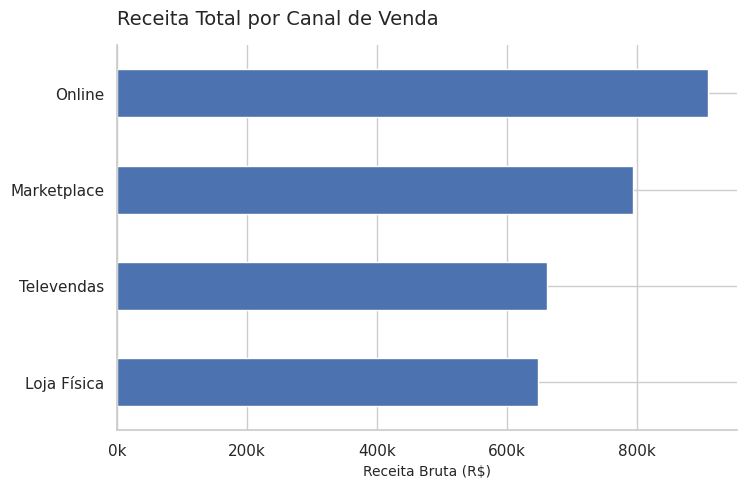

In [4]:
# 1. Agrupar receita por canal_venda e ordenar
receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=True)

# 2. Criar o gráfico
plt.figure(figsize=(8, 5))
ax = receita_canal.plot(kind='barh', color='#4C72B0')

# 3. Formatação
plt.title('Receita Total por Canal de Venda', fontsize=14, loc='left', pad=15)
plt.xlabel('Receita Bruta (R$)', fontsize=10)
plt.ylabel('') # Ocultando o label do eixo Y pois as categorias já são explicativas

# 4. Limpeza (Removendo bordas superior e direita)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Formatando o eixo X para melhor leitura
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f}k'))

plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso

- ***O canal Online lidera a geração de caixa com quase R$ 910 mil, enquanto a Loja Física fica na retaguarda com R$ 647 mil. Uma ação tática seria investigar se o custo operacional da Loja Física justifica sua permanência no formato atual ou se o investimento deve ser redirecionado para tráfego Online.***

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


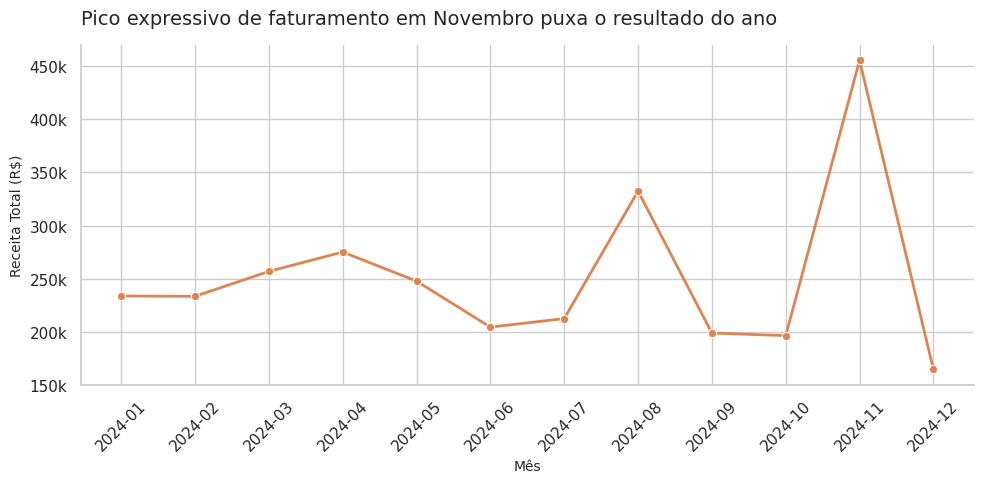

In [5]:
# 1. Agrupar receita por mês
receita_mes = df.groupby('mes')['receita'].sum().sort_index()

# 2. Criar o gráfico
plt.figure(figsize=(10, 5))
ax = sns.lineplot(x=receita_mes.index, y=receita_mes.values, marker='o', linewidth=2, color='#DD8452')

# 3. Formatação
plt.title('Pico expressivo de faturamento em Novembro puxa o resultado do ano', fontsize=14, loc='left', pad=15)
plt.xlabel('Mês', fontsize=10)
plt.ylabel('Receita Total (R$)', fontsize=10)
plt.xticks(rotation=45)

# 4. Limpeza
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

### Insight obrigatório
Responda:
- Existe sazonalidade? Sim. O primeiro semestre é relativamente estável na casa dos R$ 200k-R$ 270k, mas há picos claros no segundo semestre.

- Há meses de pico? Novembro apresenta um pico massivo (R$ 455 mil), quase o dobro da média dos outros meses, e Agosto também se destaca.

- O título ajuda? Sim, o título já entrega a conclusão (o pico de novembro) antes mesmo do gestor interpretar o desenho da linha.


## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


/tmp/ipykernel_6131/837417614.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='segmento', y='margem_lucro', data=df, palette='Set2', width=0.5)


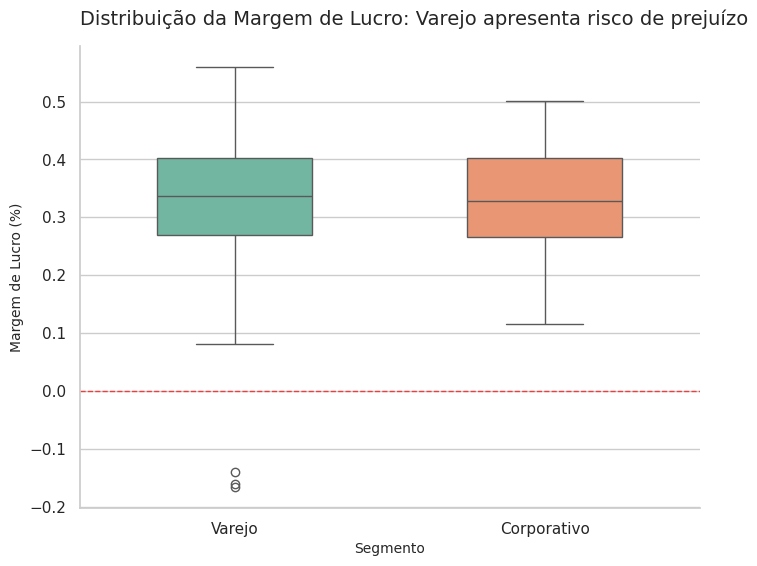

In [6]:
plt.figure(figsize=(8, 6))

# Criando o Boxplot
ax = sns.boxplot(x='segmento', y='margem_lucro', data=df, palette='Set2', width=0.5)

# Formatação
plt.title('Distribuição da Margem de Lucro: Varejo apresenta risco de prejuízo', fontsize=14, loc='left', pad=15)
plt.xlabel('Segmento', fontsize=10)
plt.ylabel('Margem de Lucro (%)', fontsize=10)

# Limpeza
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Linha de referência no zero
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.show()

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


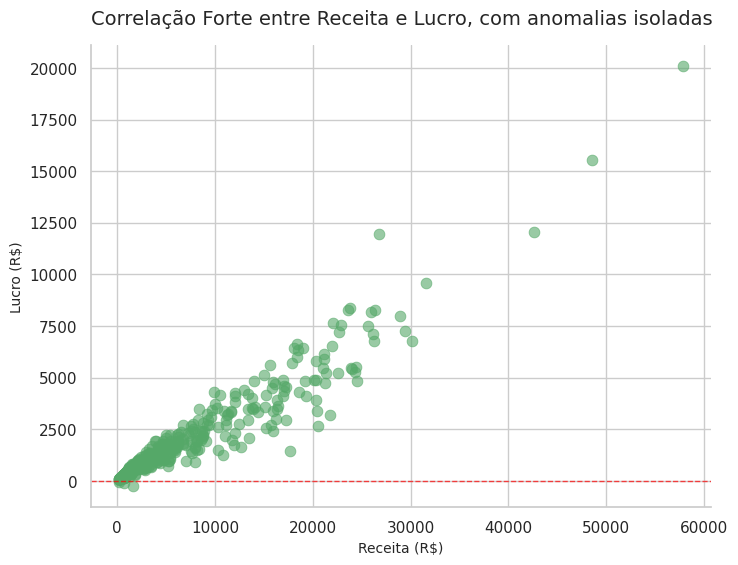

In [7]:
plt.figure(figsize=(8, 6))

# Criando o scatter plot
ax = sns.scatterplot(x='receita', y='lucro', data=df, alpha=0.6, color='#55A868', s=60, edgecolor=None)

# Formatação
plt.title('Correlação Forte entre Receita e Lucro, com anomalias isoladas', fontsize=14, loc='left', pad=15)
plt.xlabel('Receita (R$)', fontsize=10)
plt.ylabel('Lucro (R$)', fontsize=10)

# Limpeza e Referência
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


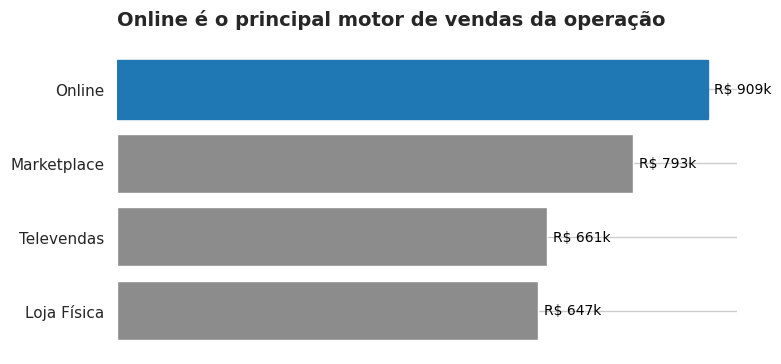

In [8]:
# Refazendo o gráfico de barras com extrema simplicidade (minimalista)
receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(receita_canal.index, receita_canal.values, color='#8C8C8C')

# Destacando apenas o líder
bars[-1].set_color('#1F77B4')

plt.title('Online é o principal motor de vendas da operação', loc='left', fontsize=14, fontweight='bold', pad=15)

# Removendo TODOS os eixos e bordas (Edward Tufte style - data ink ratio)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.set_visible(False) # Removendo o eixo X numérico

# Adicionando os valores diretamente nas barras para não precisar do eixo X
for i, v in enumerate(receita_canal.values):
    ax.text(v + 10000, i, f'R$ {v/1000:.0f}k', va='center', fontsize=10, color='black')

plt.show()

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?

- Por que gráfico de pizza com muitas categorias costuma falhar? O cérebro humano é péssimo em estimar ângulos e áreas de fatias. Com muitas categorias (mais de 3 ou 4), fatias pequenas se tornam indistinguíveis, exigindo que o usuário leia a legenda constantemente. Um gráfico de barras seria muito mais preciso.

Por que o 3D atrapalha comparações? A perspectiva geométrica distorce os dados. Uma "fatia da pizza" que está desenhada na frente no 3D parece visualmente muito maior do que a fatia desenhada no fundo, mesmo que ambas tenham o mesmo valor percentual nos dados reais.

Por que usar muitas cores sem intenção gera confusão cognitiva? Se cada barra de um ranking tiver uma cor do arco-íris, o cérebro do usuário vai tentar entender "o que a cor vermelha significa?" quando não significa nada. Cores devem ser usadas para agrupar categorias iguais ou destacar o que importa (cor-como-dado), não para decorar a tela.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
# Desafio extra opcional


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
